# Semantic Retrieval Pipeline using Docling Outputs

This notebook builds a simple semantic retrieval system using OCR outputs generated from the same Swahili document with three different OCR engines:

- Tesseract
- EasyOCR
- RapidOCR

We move from raw text → cleaned text → structured chunks → embeddings → retrieval.

## 1) Objective
We want to answer one key question:

Can OCR-generated Markdown files be turned into a searchable knowledge base?
This also helps evaluate whether different OCR engines produce outputs that are usable for downstream retrieval tasks.

To test this, we:
1. Clean the text
2. Break it into smaller chunks
3. Convert chunks into embeddings
4. Retrieve the most relevant chunks based on a query

## 2) Methodology Overview 
Pipeline steps:

1. Load OCR outputs
2. Clean text slightly
3. Split text into chunks
4. Generate embeddings using SentenceTransformers
5. Perform similarity-based retrieval

This mimics the core idea behind RAG systems.

## 3) Installing Embedding Dependencies

Before running the retrieval pipeline, we need to install the `sentence-transformers` library.

This library is used to generate embeddings, which allow us to compare text based on meaning rather than exact words.

To ensure the package is installed in the same environment as the notebook, we use the Python executable linked to the current kernel:

In [1]:
import sys
!{sys.executable} -m pip install sentence-transformers

'c:\Users\hp\Data' is not recognized as an internal or external command,
operable program or batch file.


## 4) Imports
We import the tools needed for:
- embeddings (SentenceTransformer)
- numerical operations (numpy)
- text cleaning (re)

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import re

c:\Users\hp\Data Science\outreachy-docling-task\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5) Load Files 
We load the Markdown outputs generated earlier using Docling.

These are the same files we analyzed in the previous notebook.

In [6]:
with open("../03-outputs/tesseract_outputs/Swahili-words-and-phrases-for-travelers.md", "r", encoding="utf-8") as f:
    tesseract_text = f.read()

with open("../03-outputs/easy_ocr_outputs/swahili_easyocr.md", "r", encoding="utf-8") as f:
    easyocr_text = f.read()

with open("../03-outputs/rapidocr_outputs/Swahili-words-and-phrases-for-travelers.md", "r", encoding="utf-8") as f:
     rapidocr_text = f.read()

## 6) Clean the text 
OCR output can sometimes include unnecessary spacing or formatting issues.

Here we lightly clean the text by:
- reducing excessive newlines
- trimming whitespace

This helps improve chunking and embeddings later.

In [7]:
def clean_text(text):
    text = re.sub(r"\n{2,}", "\n\n", text)
    return text.strip()

tesseract_text = clean_text(tesseract_text)
easyocr_text = clean_text(easyocr_text)
rapidocr_text = clean_text(rapidocr_text)

## 7) Chunking the text into smaller pieces

Instead of embedding the entire document at once, we split it into smaller chunks.

Why?
- Embeddings work better on smaller, meaningful pieces
- Retrieval becomes more precise

We split text into chunks of ~120 words.

In [8]:
def chunk_text(text, chunk_size=120):
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)
    return chunks

tesseract_chunks = chunk_text(tesseract_text)
easyocr_chunks = chunk_text(easyocr_text)
rapidocr_chunks = chunk_text(rapidocr_text)

print("Tesseract chunks:", len(tesseract_chunks))
print("EasyOCR chunks:", len(easyocr_chunks))
print("RapidOCR chunks:", len(rapidocr_chunks))

Tesseract chunks: 15
EasyOCR chunks: 15
RapidOCR chunks: 15


## 8) Combine Chunks with Labels 
We store each chunk together with the OCR engine that produced it.

This helps us track which engine each retrieved result came from.

In [10]:
documents = []

for chunk in tesseract_chunks:
    documents.append({"source": "Tesseract", "text": chunk})

for chunk in easyocr_chunks:
    documents.append({"source": "EasyOCR", "text": chunk})

for chunk in rapidocr_chunks:
    documents.append({"source": "RapidOCR", "text": chunk})

print("Total chunks:", len(documents))

Total chunks: 45


## 9) Load Embedding Model
We use a pre-trained embedding model from SentenceTransformers.

This model converts text into numerical vectors that capture meaning.

In [12]:
model = SentenceTransformer("all-MiniLM-L6-v2")

## 10) Create Embeddings 
We convert all text chunks into embeddings.

Each chunk becomes a vector representation that we can compare mathematically.

In [13]:
texts = [doc["text"] for doc in documents]
embeddings = model.encode(texts)

print("Embedding shape:", np.array(embeddings).shape)

Embedding shape: (45, 384)


## 11) Retrieval Function
This function takes a query and returns the most relevant chunks.

Steps:
1. Convert query into embedding
2. Compute similarity with all document embeddings
3. Return top matches

In [14]:
def retrieve(query, documents, embeddings, model, top_k=3):
    query_embedding = model.encode([query])[0]
    scores = np.dot(embeddings, query_embedding)

    top_indices = np.argsort(scores)[-top_k:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            "source": documents[idx]["source"],
            "text": documents[idx]["text"],
            "score": float(scores[idx])
        })
    return results

## 12) Test Query 1
We test a query related to Swahili greetings.

In [15]:
results = retrieve("How do I greet someone in Swahili?", documents, embeddings, model)

for i, r in enumerate(results, 1):
    print(f"Result {i}")
    print("Engine:", r["source"])
    print("Score:", round(r["score"], 4))
    print(r["text"][:500])
    print("-" * 80)

Result 1
Engine: RapidOCR
Score: 0.4661
nawe Goodbye Kwaheri (See you) later! (Tutaonana) baadaye Good day (as goodbye) Siku njema Good evening (as goodbye) Jioni njema Good night (as goodbye) Usiku mwema Sleep well Lala salama ## COURTESIES &amp; (DIS)AGREEMENTS Yes Ndiyo Do you understand? Unaelewa? No Hapana I understand Naelewa OK Sawa I don't understand Sielewi Thank you Ahsante (to 1 person) I don't speak Swahili Siongei Kiswahili Ahsanteni (to more than 1 person) Could you repeat? Sema tena (You're) welcome Karibu (to 1 person)
--------------------------------------------------------------------------------
Result 2
Engine: EasyOCR
Score: 0.4661
nawe Goodbye Kwaheri (See you) later! (Tutaonana) baadaye Good day (as goodbye) Siku njema Good evening (as goodbye) Jioni njema Good night (as goodbye) Usiku mwema Sleep well Lala salama ## COURTESIES &amp; (DIS)AGREEMENTS Yes Ndiyo Do you understand? Unaelewa? No Hapana I understand Naelewa OK Sawa I don't understand Sielewi Thank you 

### Observation

The retrieved results show that all three OCR engines are able to return relevant Swahili greeting-related content.

Tesseract and RapidOCR tend to return slightly more structured and readable chunks, while EasyOCR results are still relevant but may include minor formatting inconsistencies.

Overall, all three outputs are usable for basic semantic retrieval.

## 13) Test Query 2
We test a second query related to directions in Swahili.

In [16]:
results = retrieve("How do I ask for directions in Swahili?", documents, embeddings, model)

for i, r in enumerate(results, 1):
    print(f"Result {i}")
    print("Engine:", r["source"])
    print("Score:", round(r["score"], 4))
    print(r["text"][:500])
    print("-" * 80)

Result 1
Engine: RapidOCR
Score: 0.4689
| Train | Treni | | Road | Barabara | Tuktuk | Bajaji | | Are you on the way? | Uko njiani? | Motorbike taxi | Bodaboda | | I'm on the way | Niko njiani | Bicycle | Baiskeli | | We've arrived | Tumefika | Airplane | Ndege | | Straight forward | Moja kwa moja | What time does the …leave? | … inaondoka saa ngapi? | | A little bit futher (forward) | Mbele | Is there a …going to…? | Kuna… kwenda …? | | To the right | Kwa kulia | I want to get off here | Nataka kushuka hapa | | To the left | Kwa kush
--------------------------------------------------------------------------------
Result 2
Engine: Tesseract
Score: 0.4689
| Train | Treni | | Road | Barabara | Tuktuk | Bajaji | | Are you on the way? | Uko njiani? | Motorbike taxi | Bodaboda | | I'm on the way | Niko njiani | Bicycle | Baiskeli | | We've arrived | Tumefika | Airplane | Ndege | | Straight forward | Moja kwa moja | What time does the …leave? | … inaondoka saa ngapi? | | A little bit futher 

### Observation

The second query confirms that the retrieval pipeline works consistently across different types of questions within the same document.

All three OCR engines successfully return direction-related phrases, showing that the extracted text retains enough semantic meaning for retrieval tasks.

However, small differences in formatting and noise across engines may influence how clean or readable the retrieved chunks are.

## 14) Supporting Setup 

Below is the setup step where we installed the embedding model dependency required for semantic search.

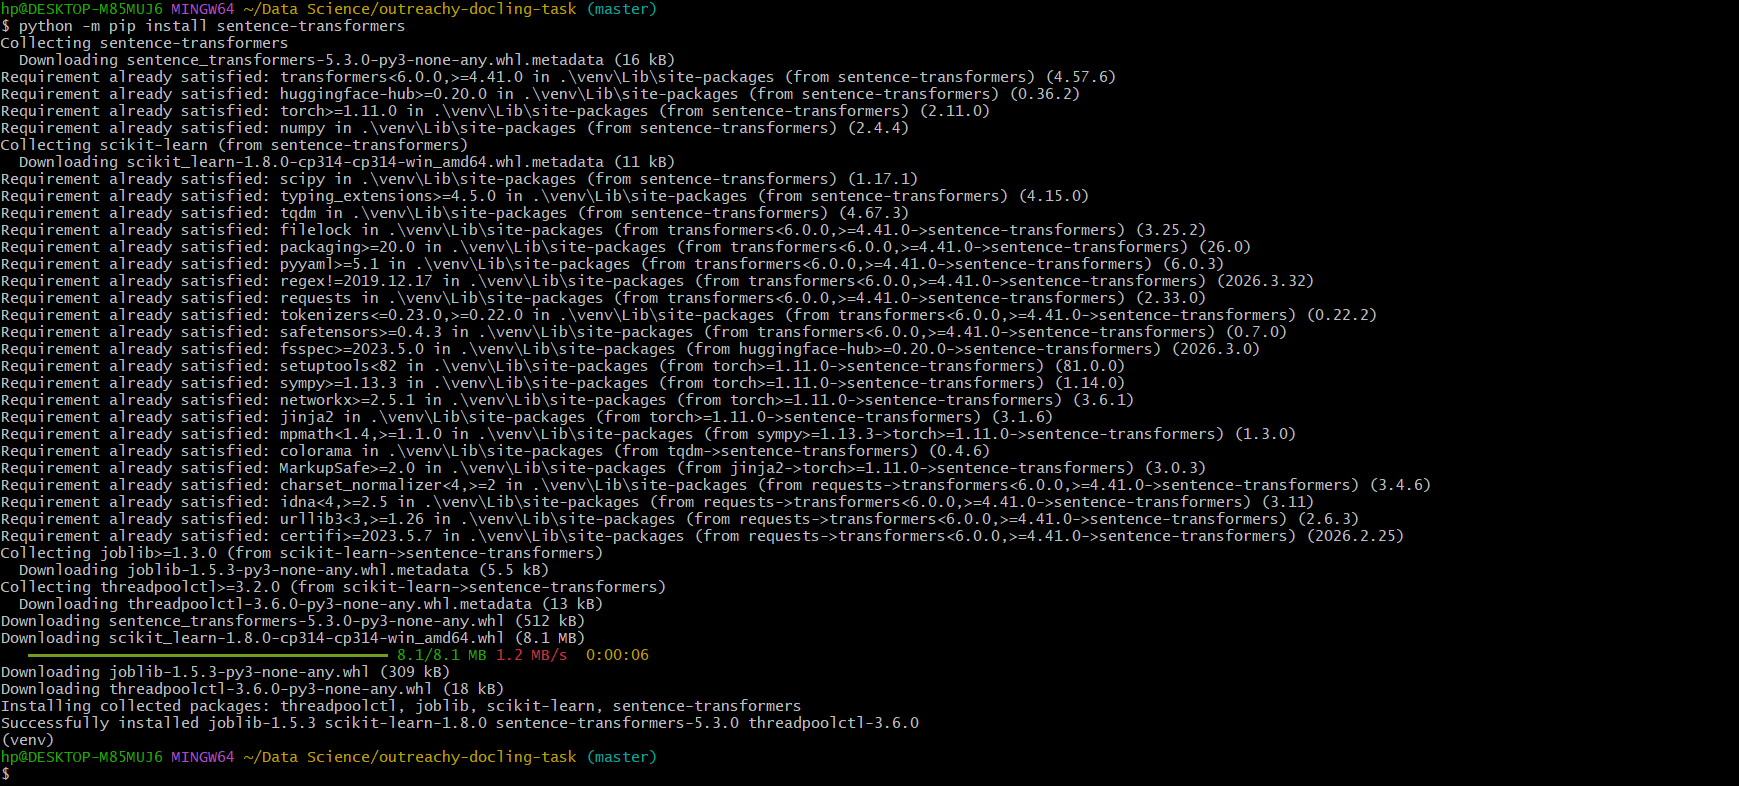

## 15) Key Notes

This is not a full chatbot.

It is a retrieval system that:
- finds relevant information
- returns it without generating new text

Pipeline recap:
1. OCR (Docling)
2. Markdown output
3. Chunking
4. Embeddings
5. Retrieval

This is the foundation of RAG systems.

## Conclusion 

This experiment shows that OCR-processed documents can be used for semantic retrieval.

However:
- OCR noise affects embedding quality
- Cleaning improves results
- Chunking is essential for performance

Overall:
Overall, the outputs generated through Docling are usable for downstream AI workflows such as semantic retrieval and RAG.
